In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns

## Helper Classes

In [2]:
class ExploratoryDataAnalysis:
    def __init__(self, str_uri, str_dirname_output):
        self.str_uri = str_uri
        self.str_dirname_output = str_dirname_output
        self.df_data = None

    def import_data(self):
        self.df_data = pd.read_parquet(self.str_uri)
        print(f'Data loaded: {self.df_data.shape[0]:,} rows, {self.df_data.shape[1]} columns')
        return self

    def plot_group_sizes(self):
        fig, ax = plt.subplots(figsize=(8, 5))
        ser_counts = self.df_data['version'].value_counts()
        ser_counts.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'], edgecolor='black')
        ax.set_title('Players per Test Group', fontsize=14, y=1.02)
        ax.set_xlabel('Group')
        ax.set_ylabel('Number of Players')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
        for i, (str_label, int_val) in enumerate(ser_counts.items()):
            ax.text(i, int_val + 200, f'{int_val:,}', ha='center', fontsize=11)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/01_group_sizes.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_retention_by_group(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for idx, str_col in enumerate(['retention_1', 'retention_7']):
            df_grouped = self.df_data.groupby('version')[str_col].mean().reset_index()
            axes[idx].bar(df_grouped['version'], df_grouped[str_col] * 100,
                          color=['#4C72B0', '#DD8452'], edgecolor='black')
            str_day = '1-Day' if str_col == 'retention_1' else '7-Day'
            axes[idx].set_title(f'{str_day} Retention by Group', fontsize=14, y=1.02)
            axes[idx].set_xlabel('Group')
            axes[idx].set_ylabel('Retention Rate (%)')
            for i, flt_val in enumerate(df_grouped[str_col]):
                axes[idx].text(i, flt_val * 100 + 0.2, f'{flt_val*100:.2f}%', ha='center', fontsize=11)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/02_retention_by_group.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_gamerounds_distribution(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for idx, str_group in enumerate(self.df_data['version'].unique()):
            ser_rounds = self.df_data.loc[self.df_data['version'] == str_group, 'sum_gamerounds']
            ser_clipped = ser_rounds.clip(upper=ser_rounds.quantile(0.99))
            axes[idx].hist(ser_clipped, bins=50, color=['#4C72B0', '#DD8452'][idx],
                           edgecolor='black', alpha=0.8)
            axes[idx].set_title(f'Game Rounds Distribution ({str_group})', fontsize=14, y=1.02)
            axes[idx].set_xlabel('Game Rounds Played')
            axes[idx].set_ylabel('Number of Players')
            axes[idx].axvline(ser_rounds.median(), color='red', linestyle='--',
                              label=f'Median: {ser_rounds.median():.0f}')
            axes[idx].legend()
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/03_gamerounds_distribution.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_gamerounds_boxplot(self):
        df_clipped = self.df_data.copy()
        flt_upper = df_clipped['sum_gamerounds'].quantile(0.95)
        df_clipped = df_clipped[df_clipped['sum_gamerounds'] <= flt_upper]
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=df_clipped, x='version', y='sum_gamerounds', ax=ax,
                    palette=['#4C72B0', '#DD8452'])
        ax.set_title('Game Rounds by Group (Clipped at 95th Percentile)', fontsize=14, y=1.02)
        ax.set_xlabel('Group')
        ax.set_ylabel('Game Rounds Played')
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/04_gamerounds_boxplot.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_retention_vs_gamerounds(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for idx, str_col in enumerate(['retention_1', 'retention_7']):
            df_grouped = self.df_data.groupby([str_col, 'version'])['sum_gamerounds'].median().reset_index()
            str_day = '1-Day' if str_col == 'retention_1' else '7-Day'
            for i, str_group in enumerate(self.df_data['version'].unique()):
                df_sub = df_grouped[df_grouped['version'] == str_group]
                axes[idx].bar(
                    [x + i * 0.35 for x in range(len(df_sub))],
                    df_sub['sum_gamerounds'],
                    width=0.35, label=str_group,
                    color=['#4C72B0', '#DD8452'][i], edgecolor='black'
                )
            axes[idx].set_title(f'Median Game Rounds by {str_day} Retention', fontsize=14, y=1.02)
            axes[idx].set_xlabel(f'{str_day} Retention')
            axes[idx].set_ylabel('Median Game Rounds')
            axes[idx].set_xticks([x + 0.175 for x in range(2)])
            axes[idx].set_xticklabels(['Not Retained', 'Retained'])
            axes[idx].legend()
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/05_retention_vs_gamerounds.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def print_summary_table(self):
        print('\n=== GROUP SUMMARY ===')
        df_summary = self.df_data.groupby('version').agg(
            int_n_players=('userid', 'count'),
            flt_retention_1=('retention_1', 'mean'),
            flt_retention_7=('retention_7', 'mean'),
            flt_mean_rounds=('sum_gamerounds', 'mean'),
            flt_median_rounds=('sum_gamerounds', 'median')
        ).reset_index()
        df_summary['flt_retention_1'] = df_summary['flt_retention_1'].map('{:.4f}'.format)
        df_summary['flt_retention_7'] = df_summary['flt_retention_7'].map('{:.4f}'.format)
        df_summary['flt_mean_rounds'] = df_summary['flt_mean_rounds'].map('{:.2f}'.format)
        print(df_summary.to_string(index=False))
        return self

## Constants

In [3]:
str_bucket = 'ab-testing-demo-repo'
str_task = 'eda'
str_dirname_output = './output'
str_uri = f's3://{str_bucket}/00_data_collection/cookie_cats.parquet'

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass
print(f'Output directory ready: {str_dirname_output}')

Output directory ready: ./output


## Run EDA

In [5]:
cls_eda = ExploratoryDataAnalysis(str_uri, str_dirname_output)
cls_eda.import_data()

Data loaded: 90,189 rows, 5 columns


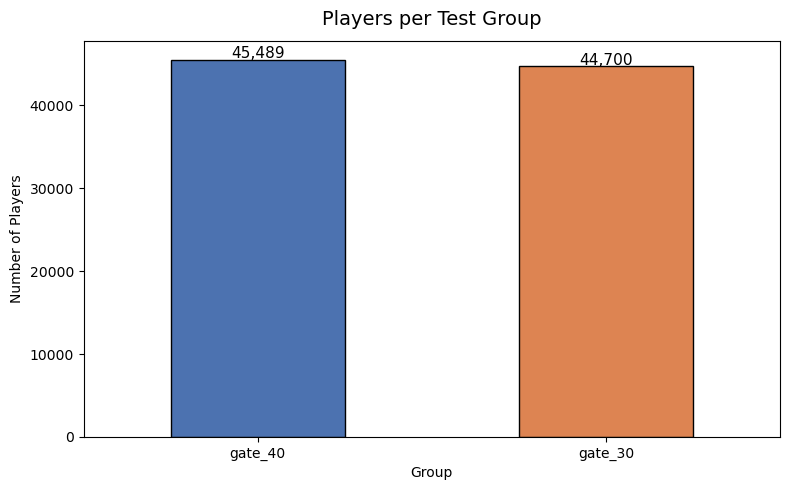

In [6]:
cls_eda.plot_group_sizes()

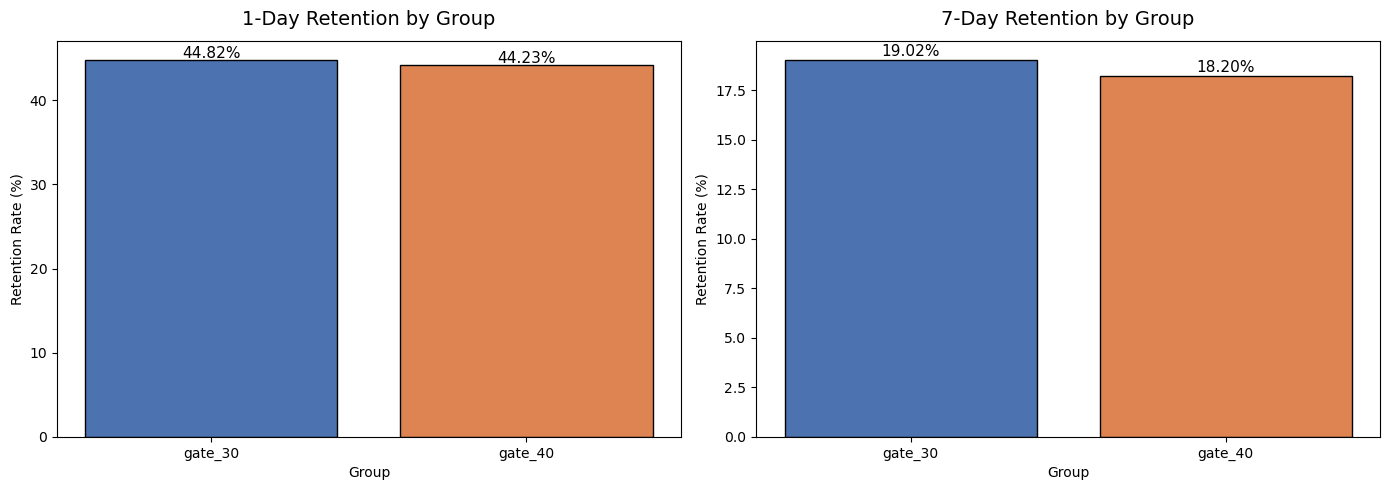

In [7]:
cls_eda.plot_retention_by_group()

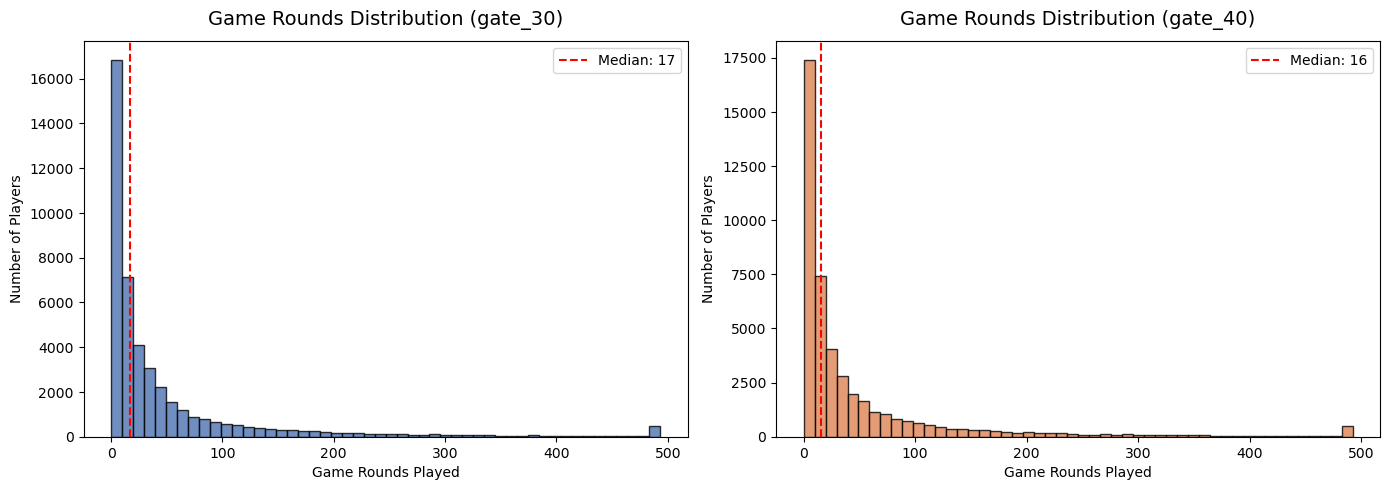

In [8]:
cls_eda.plot_gamerounds_distribution()

/tmp/ipykernel_9126/842879213.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clipped, x='version', y='sum_gamerounds', ax=ax,


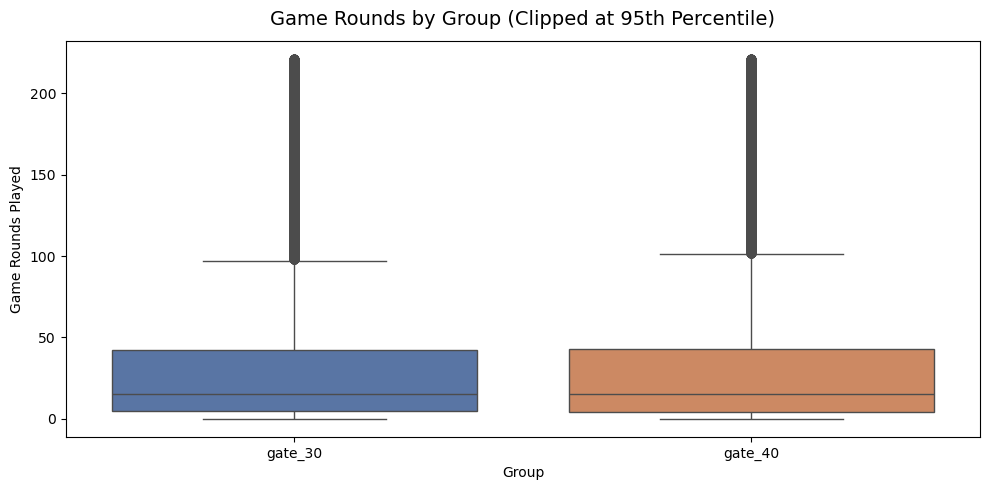

In [9]:
cls_eda.plot_gamerounds_boxplot()

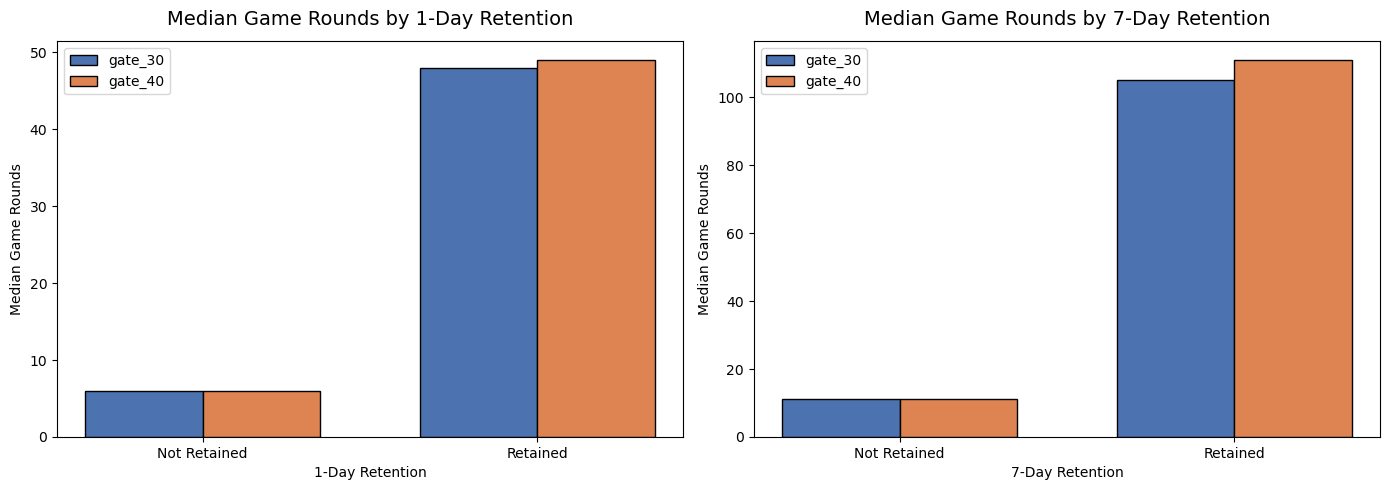

In [10]:
cls_eda.plot_retention_vs_gamerounds()

In [11]:
cls_eda.print_summary_table()


=== GROUP SUMMARY ===
version  int_n_players flt_retention_1 flt_retention_7 flt_mean_rounds  flt_median_rounds
gate_30          44700          0.4482          0.1902           52.46               17.0
gate_40          45489          0.4423          0.1820           51.30               16.0


## Completion

In [12]:
print('\n=== EDA COMPLETE ===')
print(f'Visualizations saved to: {str_dirname_output}')


=== EDA COMPLETE ===
Visualizations saved to: ./output
